# 📈 Linear Regression — OLS, Gradient Descent & Assumptions

The first algorithm in this series' Regression category, and the foundation every later regression topic (Ridge/Lasso, SVR, tree-based regressors) will be compared against. This notebook derives Ordinary Least Squares two different ways (closed-form and gradient descent), verifies they agree, then checks the assumptions OLS actually depends on.

📖 Full mathematical explanation (normal equation derivation, gradient descent convergence, assumption diagnostics): [README.md](README.md)


## 1. Setup & Datasets

A synthetic 1D dataset (so the fitted line, cost surface, and gradient descent path can all be visualized directly) plus the Diabetes dataset (real, multivariate, for assumption-checking).


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
true_slope, true_intercept = 2.5, 1.0
n_samples = 100
X_1d = np.random.uniform(0, 5, n_samples)
y_1d = true_intercept + true_slope * X_1d + np.random.normal(0, 1.2, n_samples)

X_1d_train, X_1d_test, y_1d_train, y_1d_test = train_test_split(
    X_1d.reshape(-1, 1), y_1d, test_size=0.25, random_state=42
)
print(f"1D dataset: {n_samples} points, true relationship: y = {true_intercept} + {true_slope}*x + noise")
print(f"Train: {X_1d_train.shape}, Test: {X_1d_test.shape}")


1D dataset: 100 points, true relationship: y = 1.0 + 2.5*x + noise
Train: (75, 1), Test: (25, 1)


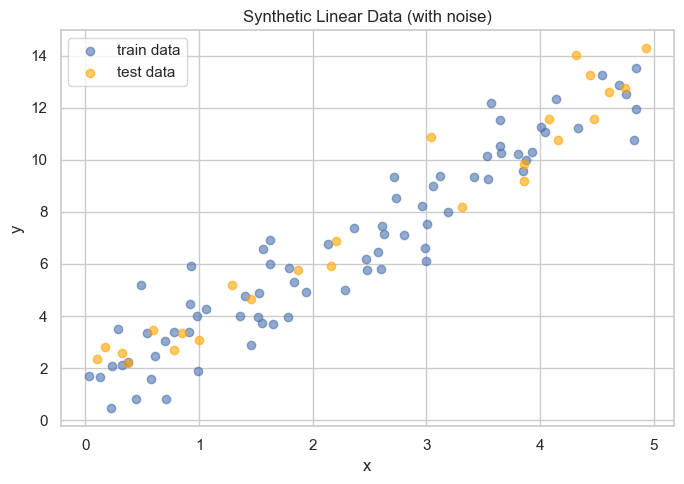

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_1d_train, y_1d_train, alpha=0.6, label="train data")
ax.scatter(X_1d_test, y_1d_test, alpha=0.6, color="orange", label="test data")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Synthetic Linear Data (with noise)")
ax.legend()
plt.tight_layout()
plt.show()


## 2. The Cost Function — Mean Squared Error

$$J(\beta_0, \beta_1) = \frac{1}{2n}\sum_{i=1}^n (y_i - (\beta_0 + \beta_1 x_i))^2$$

The $\frac{1}{2}$ is a calculus convenience (it cancels the 2 from differentiating the square) and doesn't change which $(\beta_0, \beta_1)$ minimizes $J$.


In [4]:
def compute_cost(X, y, beta0, beta1):
    predictions = beta0 + beta1 * X.ravel()
    return np.mean((y - predictions) ** 2) / 2

beta0_range = np.linspace(-3, 5, 60)
beta1_range = np.linspace(0, 5, 60)
B0, B1 = np.meshgrid(beta0_range, beta1_range)
cost_surface = np.zeros_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        cost_surface[i, j] = compute_cost(X_1d_train, y_1d_train, B0[i, j], B1[i, j])

print(f"Cost surface computed over {B0.shape[0]}x{B0.shape[1]} grid, min cost in grid: {cost_surface.min():.4f}")


Cost surface computed over 60x60 grid, min cost in grid: 0.6128


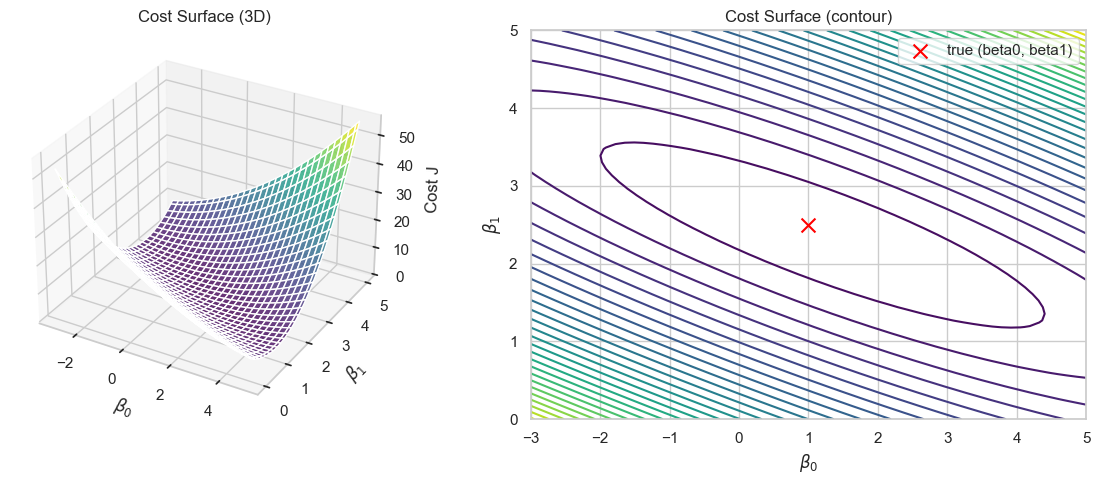

In [5]:
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(B0, B1, cost_surface, cmap="viridis", alpha=0.8)
ax1.set_xlabel(r"$\beta_0$"); ax1.set_ylabel(r"$\beta_1$"); ax1.set_zlabel("Cost J")
ax1.set_title("Cost Surface (3D)")

ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contour(B0, B1, cost_surface, levels=30, cmap="viridis")
ax2.scatter(true_intercept, true_slope, color="red", marker="x", s=100, label="true (beta0, beta1)")
ax2.set_xlabel(r"$\beta_0$"); ax2.set_ylabel(r"$\beta_1$")
ax2.set_title("Cost Surface (contour)")
ax2.legend()
plt.tight_layout()
plt.show()


## 3. Closed-Form Solution — the Normal Equation

Setting $\nabla J = 0$ and solving analytically gives:

$$\hat\beta = (X^TX)^{-1}X^Ty$$

No iteration needed -- exact in one step, as long as $X^TX$ is invertible.


In [6]:
def normal_equation(X, y):
    X_with_bias = np.c_[np.ones(len(X)), X]
    beta = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
    return beta

beta_normal_eq = normal_equation(X_1d_train, y_1d_train)
print(f"Normal equation solution: beta0={beta_normal_eq[0]:.4f}, beta1={beta_normal_eq[1]:.4f}")
print(f"True values:              beta0={true_intercept}, beta1={true_slope}")


Normal equation solution: beta0=1.2025, beta1=2.3684
True values:              beta0=1.0, beta1=2.5


In [7]:
sklearn_lr = LinearRegression().fit(X_1d_train, y_1d_train)
print(f"sklearn LinearRegression: beta0={sklearn_lr.intercept_:.4f}, beta1={sklearn_lr.coef_[0]:.4f}")
print(f"Match with normal equation? {np.allclose([sklearn_lr.intercept_, sklearn_lr.coef_[0]], beta_normal_eq)}")


sklearn LinearRegression: beta0=1.2025, beta1=2.3684
Match with normal equation? True


In [8]:
y_1d_test_pred = sklearn_lr.predict(X_1d_test)
test_r2_1d = r2_score(y_1d_test, y_1d_test_pred)
test_rmse_1d = np.sqrt(mean_squared_error(y_1d_test, y_1d_test_pred))
print(f"Test R^2: {test_r2_1d:.4f}, Test RMSE: {test_rmse_1d:.4f}")
print(f"(Noise was generated with std=1.2, so RMSE close to that value indicates the model recovered the true relationship well.)")


Test R^2: 0.9415, Test RMSE: 1.0090
(Noise was generated with std=1.2, so RMSE close to that value indicates the model recovered the true relationship well.)


## 4. Gradient Descent — the Iterative Alternative

$$\beta_j := \beta_j - \eta \frac{\partial J}{\partial \beta_j}, \qquad \frac{\partial J}{\partial \beta_0} = -\frac{1}{n}\sum(y_i - \hat y_i), \qquad \frac{\partial J}{\partial \beta_1} = -\frac{1}{n}\sum(y_i - \hat y_i)x_i$$

Instead of solving exactly, gradient descent takes small steps downhill on the cost surface from Section 2.


In [9]:
def gradient_descent(X, y, learning_rate=0.1, n_iterations=1000):
    n = len(X)
    x_flat = X.ravel()
    beta0, beta1 = 0.0, 0.0
    cost_history = []
    param_history = [(beta0, beta1)]

    for _ in range(n_iterations):
        predictions = beta0 + beta1 * x_flat
        errors = predictions - y
        grad_beta0 = np.mean(errors)
        grad_beta1 = np.mean(errors * x_flat)
        beta0 -= learning_rate * grad_beta0
        beta1 -= learning_rate * grad_beta1
        cost_history.append(compute_cost(X, y, beta0, beta1))
        param_history.append((beta0, beta1))

    return beta0, beta1, cost_history, param_history

beta0_gd, beta1_gd, cost_history, param_history = gradient_descent(X_1d_train, y_1d_train, learning_rate=0.1, n_iterations=1000)
print(f"Gradient descent solution: beta0={beta0_gd:.4f}, beta1={beta1_gd:.4f}")
print(f"Normal equation solution:  beta0={beta_normal_eq[0]:.4f}, beta1={beta_normal_eq[1]:.4f}")
print(f"Match? {np.allclose([beta0_gd, beta1_gd], beta_normal_eq, atol=1e-3)}")


Gradient descent solution: beta0=1.2025, beta1=2.3684
Normal equation solution:  beta0=1.2025, beta1=2.3684
Match? True


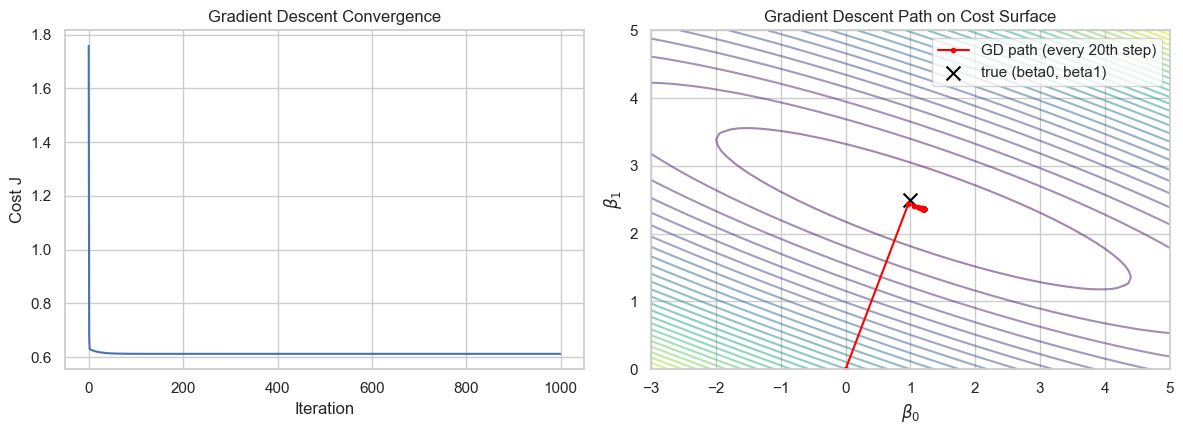

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(cost_history)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Cost J"); axes[0].set_title("Gradient Descent Convergence")

axes[1].contour(B0, B1, cost_surface, levels=30, cmap="viridis", alpha=0.5)
path = np.array(param_history[::20])
axes[1].plot(path[:, 0], path[:, 1], marker="o", markersize=3, color="red", label="GD path (every 20th step)")
axes[1].scatter(true_intercept, true_slope, color="black", marker="x", s=100, label="true (beta0, beta1)")
axes[1].set_xlabel(r"$\beta_0$"); axes[1].set_ylabel(r"$\beta_1$"); axes[1].set_title("Gradient Descent Path on Cost Surface")
axes[1].legend()
plt.tight_layout()
plt.show()


## 5. Learning Rate — Too Small, Too Large, and Just Right

The single most important gradient descent hyperparameter: too small wastes iterations, too large overshoots and can diverge entirely.


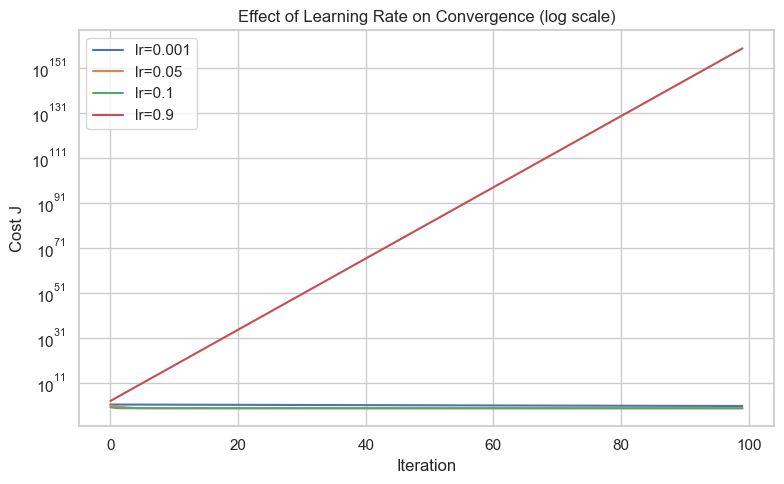

In [11]:
learning_rates = [0.001, 0.05, 0.1, 0.9]
fig, ax = plt.subplots(figsize=(8, 5))
for lr in learning_rates:
    _, _, cost_hist_lr, _ = gradient_descent(X_1d_train, y_1d_train, learning_rate=lr, n_iterations=100)
    ax.plot(cost_hist_lr, label=f"lr={lr}")
ax.set_xlabel("Iteration"); ax.set_ylabel("Cost J")
ax.set_yscale("log")
ax.set_title("Effect of Learning Rate on Convergence (log scale)")
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
_, _, cost_too_small, _ = gradient_descent(X_1d_train, y_1d_train, learning_rate=0.001, n_iterations=100)
_, _, cost_diverge, _ = gradient_descent(X_1d_train, y_1d_train, learning_rate=1.5, n_iterations=20)

print(f"lr=0.001 after 100 iterations: cost={cost_too_small[-1]:.4f} (barely moved from start)")
print(f"lr=1.5   after 20 iterations:  cost={cost_diverge[-1]:.4e} (exploding -- diverged)")
print(f"lr=1.5   cost trend (first 5 iterations): {[round(c, 2) for c in cost_diverge[:5]]}")


lr=0.001 after 100 iterations: cost=6.1734 (barely moved from start)
lr=1.5   after 20 iterations:  cost=1.0891e+43 (exploding -- diverged)
lr=1.5   cost trend (first 5 iterations): [np.float64(3304.94), np.float64(397170.45), np.float64(47738735.14), np.float64(5738066063.42), np.float64(689699935874.55)]


## 6. Why Feature Scaling Speeds Up Gradient Descent

On a single feature, scale doesn't matter much. With multiple features of very different scales, the cost surface becomes a narrow elongated valley, and gradient descent zig-zags slowly toward the minimum instead of taking a direct path.


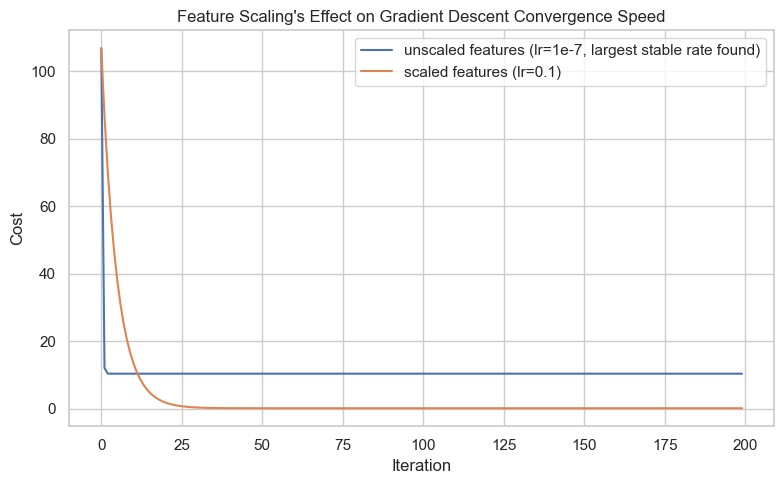

Unscaled -- cost after 200 iters: 10.3710 (lr=1e-7 is the largest rate that doesn't overflow -- even so, barely converges in 200 iterations)
Scaled   -- cost after 200 iters: 0.1308 (lr=0.1, a million times larger, converges cleanly)
-> Any unscaled learning rate above ~1e-6 overflowed to NaN/inf here -- direct evidence of how badly mismatched feature scales constrain gradient descent's usable step size.


In [13]:
X_2feat = np.column_stack([
    np.random.uniform(0, 5, 200),
    np.random.uniform(0, 5000, 200),
])
true_coefs_2feat = np.array([2.0, 0.003])
y_2feat = 1.0 + X_2feat @ true_coefs_2feat + np.random.normal(0, 0.5, 200)

def gradient_descent_multi(X, y, learning_rate=0.01, n_iterations=200):
    n, n_features = X.shape
    beta = np.zeros(n_features)
    beta0 = 0.0
    cost_history = []
    for _ in range(n_iterations):
        predictions = beta0 + X @ beta
        errors = predictions - y
        beta0 -= learning_rate * np.mean(errors)
        beta -= learning_rate * (X.T @ errors) / n
        cost_history.append(np.mean(errors ** 2) / 2)
    return beta0, beta, cost_history

_, _, cost_unscaled = gradient_descent_multi(X_2feat, y_2feat, learning_rate=1e-7, n_iterations=200)

scaler_demo = StandardScaler()
X_2feat_scaled = scaler_demo.fit_transform(X_2feat)
_, _, cost_scaled = gradient_descent_multi(X_2feat_scaled, y_2feat, learning_rate=0.1, n_iterations=200)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_unscaled, label="unscaled features (lr=1e-7, largest stable rate found)")
ax.plot(cost_scaled, label="scaled features (lr=0.1)")
ax.set_xlabel("Iteration"); ax.set_ylabel("Cost")
ax.set_title("Feature Scaling's Effect on Gradient Descent Convergence Speed")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Unscaled -- cost after 200 iters: {cost_unscaled[-1]:.4f} (lr=1e-7 is the largest rate that doesn't overflow -- even so, barely converges in 200 iterations)")
print(f"Scaled   -- cost after 200 iters: {cost_scaled[-1]:.4f} (lr=0.1, a million times larger, converges cleanly)")
print(f"-> Any unscaled learning rate above ~1e-6 overflowed to NaN/inf here -- direct evidence of how badly mismatched feature scales constrain gradient descent's usable step size.")


## 7. Batch, Stochastic, and Mini-Batch Gradient Descent

Batch GD (above) uses the full training set for every gradient step. Stochastic GD uses one random point per step (noisy but fast per-step); Mini-batch splits the difference.


In [14]:
def sgd(X, y, learning_rate=0.05, n_epochs=50):
    n = len(X)
    x_flat = X.ravel()
    beta0, beta1 = 0.0, 0.0
    cost_history = []
    rng = np.random.RandomState(0)
    for epoch in range(n_epochs):
        indices = rng.permutation(n)
        for i in indices:
            pred = beta0 + beta1 * x_flat[i]
            error = pred - y[i]
            beta0 -= learning_rate * error
            beta1 -= learning_rate * error * x_flat[i]
        cost_history.append(compute_cost(X, y, beta0, beta1))
    return beta0, beta1, cost_history

def minibatch_gd(X, y, learning_rate=0.05, n_epochs=50, batch_size=16):
    n = len(X)
    x_flat = X.ravel()
    beta0, beta1 = 0.0, 0.0
    cost_history = []
    rng = np.random.RandomState(0)
    for epoch in range(n_epochs):
        indices = rng.permutation(n)
        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            xb, yb = x_flat[batch_idx], y[batch_idx]
            pred = beta0 + beta1 * xb
            errors = pred - yb
            beta0 -= learning_rate * errors.mean()
            beta1 -= learning_rate * (errors * xb).mean()
        cost_history.append(compute_cost(X, y, beta0, beta1))
    return beta0, beta1, cost_history

beta0_sgd, beta1_sgd, cost_sgd = sgd(X_1d_train, y_1d_train)
beta0_mb, beta1_mb, cost_mb = minibatch_gd(X_1d_train, y_1d_train)
_, _, cost_batch_epochs, _ = gradient_descent(X_1d_train, y_1d_train, learning_rate=0.1, n_iterations=50)

print(f"Batch GD (50 iters):      beta0={param_history[50][0]:.4f}, beta1={param_history[50][1]:.4f}")
print(f"SGD (50 epochs):          beta0={beta0_sgd:.4f}, beta1={beta1_sgd:.4f}")
print(f"Mini-batch GD (50 epochs): beta0={beta0_mb:.4f}, beta1={beta1_mb:.4f}")


Batch GD (50 iters):      beta0=1.0921, beta1=2.4047
SGD (50 epochs):          beta0=1.2419, beta1=2.2767
Mini-batch GD (50 epochs): beta0=1.1669, beta1=2.3158


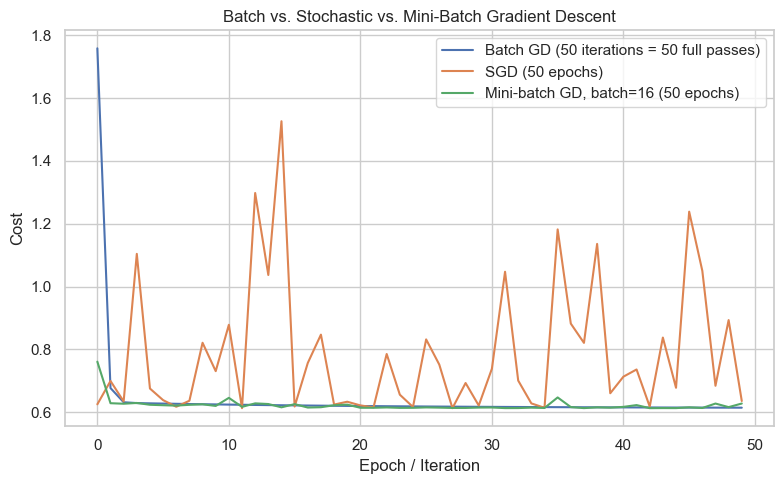

-> SGD's per-epoch cost is noisier (one point at a time) but often reaches a similar final cost faster in wall-clock time on large datasets since it updates far more frequently per pass.


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_batch_epochs, label="Batch GD (50 iterations = 50 full passes)")
ax.plot(cost_sgd, label="SGD (50 epochs)")
ax.plot(cost_mb, label="Mini-batch GD, batch=16 (50 epochs)")
ax.set_xlabel("Epoch / Iteration"); ax.set_ylabel("Cost")
ax.set_title("Batch vs. Stochastic vs. Mini-Batch Gradient Descent")
ax.legend()
plt.tight_layout()
plt.show()
print("-> SGD's per-epoch cost is noisier (one point at a time) but often reaches a similar final cost faster in wall-clock time on large datasets since it updates far more frequently per pass.")


In [16]:
final_costs = pd.DataFrame({
    "method": ["Batch GD (50 iters)", "SGD (50 epochs)", "Mini-batch GD (50 epochs)"],
    "final_cost": [round(cost_batch_epochs[-1], 5), round(cost_sgd[-1], 5), round(cost_mb[-1], 5)],
    "true_optimal_cost": [round(compute_cost(X_1d_train, y_1d_train, *beta_normal_eq), 5)] * 3,
})
final_costs


,method,final_cost,true_optimal_cost
0,Batch GD (50 iters),0.61436,0.6127
1,SGD (50 epochs),0.63559,0.6127
2,Mini-batch GD (50 epochs),0.62763,0.6127


In [17]:
from sklearn.linear_model import SGDRegressor
import time

sgd_sklearn = SGDRegressor(max_iter=1000, tol=1e-5, learning_rate="constant", eta0=0.01, random_state=42)
sgd_sklearn.fit(X_1d_train, y_1d_train)
print(f"sklearn SGDRegressor: beta0={sgd_sklearn.intercept_[0]:.4f}, beta1={sgd_sklearn.coef_[0]:.4f}")
print(f"Our from-scratch SGD: beta0={beta0_sgd:.4f}, beta1={beta1_sgd:.4f}")
print(f"Normal equation:      beta0={beta_normal_eq[0]:.4f}, beta1={beta_normal_eq[1]:.4f}")


sklearn SGDRegressor: beta0=1.1716, beta1=2.4215
Our from-scratch SGD: beta0=1.2419, beta1=2.2767
Normal equation:      beta0=1.2025, beta1=2.3684


In [18]:
timings = {}
t0 = time.perf_counter(); normal_equation(X_1d_train, y_1d_train); timings["Normal Equation"] = time.perf_counter() - t0
t0 = time.perf_counter(); gradient_descent(X_1d_train, y_1d_train, learning_rate=0.1, n_iterations=1000); timings["Batch GD (1000 iters)"] = time.perf_counter() - t0
t0 = time.perf_counter(); sgd(X_1d_train, y_1d_train, n_epochs=50); timings["SGD (50 epochs)"] = time.perf_counter() - t0
t0 = time.perf_counter(); minibatch_gd(X_1d_train, y_1d_train, n_epochs=50); timings["Mini-batch GD (50 epochs)"] = time.perf_counter() - t0

for name, t in timings.items():
    print(f"{name:<28}: {t*1000:.2f} ms")
print("\n-> On a dataset this small (75 training points), the normal equation's single matrix inversion is fastest; the gap would close (and eventually reverse) on much larger datasets where a single inversion of X^T X becomes the bottleneck.")


Normal Equation             : 0.13 ms
Batch GD (1000 iters)       : 12.06 ms
SGD (50 epochs)             : 2.23 ms
Mini-batch GD (50 epochs)   : 2.39 ms

-> On a dataset this small (75 training points), the normal equation's single matrix inversion is fastest; the gap would close (and eventually reverse) on much larger datasets where a single inversion of X^T X becomes the bottleneck.


## 8. Multivariate Linear Regression on Real Data

Moving from the synthetic 1D case to the Diabetes dataset (10 real features), where assumption-checking actually matters.


In [19]:
diabetes = load_diabetes(as_frame=True)
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.25, random_state=42)

lr_diabetes = LinearRegression().fit(Xd_train, yd_train)
yd_pred = lr_diabetes.predict(Xd_test)

print(f"Test R^2: {r2_score(yd_test, yd_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(yd_test, yd_pred)):.2f}")
print(f"\nCoefficients:")
for name, coef in zip(Xd.columns, lr_diabetes.coef_):
    print(f"  {name:<10}: {coef:>8.2f}")


Test R^2: 0.4849
Test RMSE: 53.37

Coefficients:
  age       :    47.75
  sex       :  -241.99
  bmi       :   531.97
  bp        :   381.56
  s1        :  -918.50
  s2        :   508.26
  s3        :   116.95
  s4        :   269.49
  s5        :   695.81
  s6        :    26.32


In [20]:
train_r2_d = r2_score(yd_train, lr_diabetes.predict(Xd_train))
test_r2_d = r2_score(yd_test, yd_pred)
print(f"Train R^2: {train_r2_d:.4f}")
print(f"Test R^2:  {test_r2_d:.4f}")
print(f"Gap: {train_r2_d - test_r2_d:.4f}  ({'small, not much overfitting' if train_r2_d - test_r2_d < 0.1 else 'notable gap, some overfitting'})")


Train R^2: 0.5190
Test R^2:  0.4849
Gap: 0.0341  (small, not much overfitting)


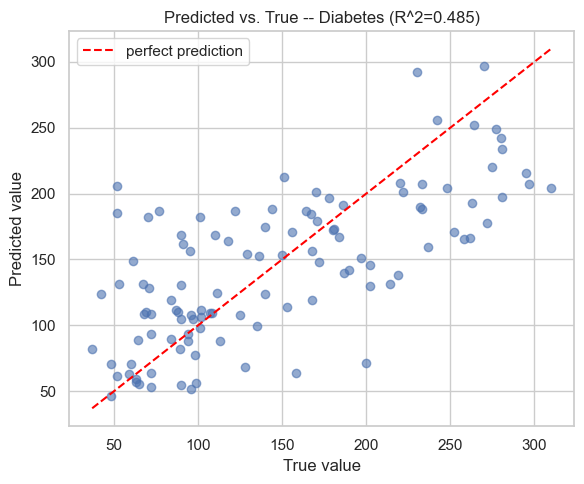

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(yd_test, yd_pred, alpha=0.6)
lims = [min(yd_test.min(), yd_pred.min()), max(yd_test.max(), yd_pred.max())]
ax.plot(lims, lims, color="red", linestyle="--", label="perfect prediction")
ax.set_xlabel("True value"); ax.set_ylabel("Predicted value")
ax.set_title(f"Predicted vs. True -- Diabetes (R^2={test_r2_d:.3f})")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Checking Linear Regression's Assumptions

OLS coefficients and their standard errors are only reliable when several assumptions roughly hold: linearity, homoscedasticity (constant residual variance), residual normality, and limited multicollinearity.


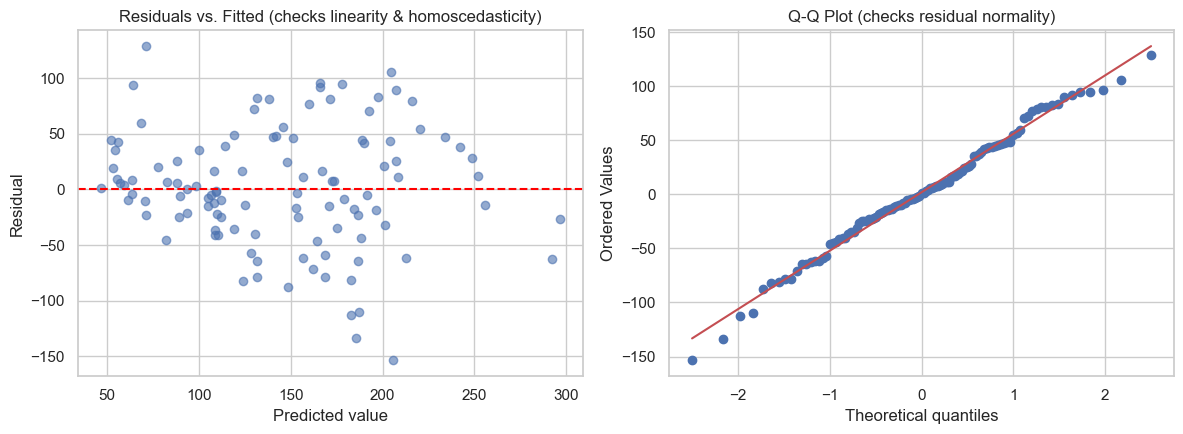

In [22]:
residuals_d = yd_test - yd_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(yd_pred, residuals_d, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted value"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs. Fitted (checks linearity & homoscedasticity)")

stats.probplot(residuals_d, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (checks residual normality)")
plt.tight_layout()
plt.show()


In [23]:
print(f"Residual mean: {residuals_d.mean():.3f} (should be near 0 for an unbiased model)")
print(f"Residual std:  {residuals_d.std():.3f}")
print(f"Residual skew: {stats.skew(residuals_d):.3f} (0 = symmetric, matches the roughly-symmetric spread visible in the Q-Q plot above)")


Residual mean: 1.865 (should be near 0 for an unbiased model)
Residual std:  53.579
Residual skew: -0.178 (0 = symmetric, matches the roughly-symmetric spread visible in the Q-Q plot above)


In [24]:
shapiro_stat, shapiro_p = stats.shapiro(residuals_d)
print(f"Shapiro-Wilk normality test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("-> p > 0.05: fail to reject normality -- residuals are consistent with a normal distribution.")
else:
    print(f"-> p <= 0.05: residuals deviate from normality at the 0.05 level (only {len(residuals_d)} test points, so this test itself has limited power).")


Shapiro-Wilk normality test: statistic=0.9906, p-value=0.6435
-> p > 0.05: fail to reject normality -- residuals are consistent with a normal distribution.


### Multicollinearity — Variance Inflation Factor (VIF)

$$VIF_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ comes from regressing feature $j$ on all other features. $VIF_j > 5$ (some use 10) flags a feature whose information substantially overlaps with the others -- its individual coefficient becomes unstable even if the model's overall fit is fine.


In [25]:
def compute_vif(X):
    vif_data = []
    for i, col in enumerate(X.columns):
        other_cols = [c for c in X.columns if c != col]
        r2_j = LinearRegression().fit(X[other_cols], X[col]).score(X[other_cols], X[col])
        vif = 1 / (1 - r2_j) if r2_j < 1 else np.inf
        vif_data.append({"feature": col, "VIF": round(vif, 2)})
    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)

vif_df = compute_vif(Xd_train)
vif_df


,feature,VIF
4,s1,54.30
5,s2,35.60
6,s3,13.84
8,s5,9.80
7,s4,9.32
2,bmi,1.53
9,s6,1.46
3,bp,1.42
1,sex,1.25
0,age,1.22


In [26]:
high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif) > 0:
    print(f"Features with VIF > 5 (meaningful multicollinearity): {high_vif['feature'].tolist()}")
else:
    print(f"No feature exceeds VIF=5 -- max VIF in this dataset is {vif_df['VIF'].max():.2f} ({vif_df.iloc[0]['feature']}), multicollinearity is not a major concern here.")


Features with VIF > 5 (meaningful multicollinearity): ['s1', 's2', 's3', 's5', 's4']


## 10. Leverage & Influential Points

Not every outlier affects the fitted line equally -- a point far from the *mean of X* (high leverage) that's also off the trend can pull the whole regression line toward itself.


In [27]:
X_influence = np.random.uniform(0, 5, 30)
y_influence = 1.0 + 2.5 * X_influence + np.random.normal(0, 0.5, 30)

X_with_outlier = np.append(X_influence, 9.5)
y_with_outlier = np.append(y_influence, 2.0)

lr_clean = LinearRegression().fit(X_influence.reshape(-1, 1), y_influence)
lr_outlier = LinearRegression().fit(X_with_outlier.reshape(-1, 1), y_with_outlier)
print(f"Slope WITHOUT outlier: {lr_clean.coef_[0]:.4f}")
print(f"Slope WITH outlier:    {lr_outlier.coef_[0]:.4f}")


Slope WITHOUT outlier: 2.4829
Slope WITH outlier:    1.1156


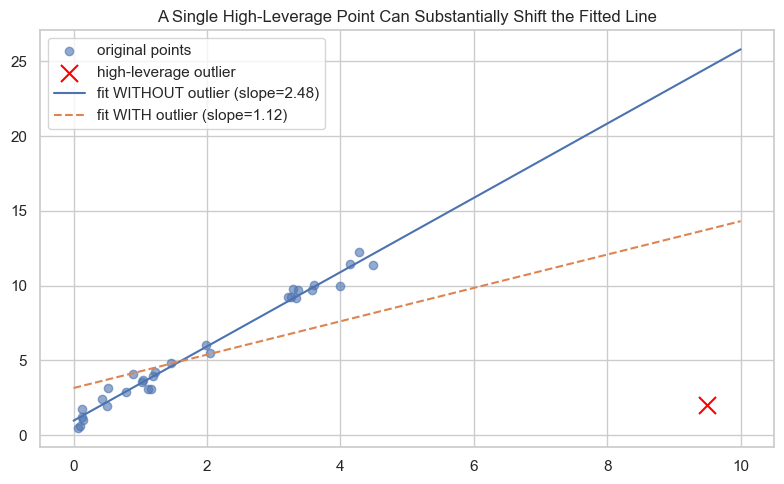

Slope changed by 1.37 (55% relative change) from a single added point.


In [28]:
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_influence, y_influence, alpha=0.6, label="original points")
ax.scatter([9.5], [2.0], color="red", marker="x", s=150, label="high-leverage outlier")
ax.plot(x_line, lr_clean.predict(x_line), label=f"fit WITHOUT outlier (slope={lr_clean.coef_[0]:.2f})")
ax.plot(x_line, lr_outlier.predict(x_line), linestyle="--", label=f"fit WITH outlier (slope={lr_outlier.coef_[0]:.2f})")
ax.legend()
ax.set_title("A Single High-Leverage Point Can Substantially Shift the Fitted Line")
plt.tight_layout()
plt.show()
print(f"Slope changed by {abs(lr_outlier.coef_[0] - lr_clean.coef_[0]):.2f} ({100*abs(lr_outlier.coef_[0] - lr_clean.coef_[0])/abs(lr_clean.coef_[0]):.0f}% relative change) from a single added point.")


## 11. Confidence Intervals for Coefficients

Beyond the point estimate $\hat\beta_j$, the standard error tells us how much that estimate would vary across different samples -- the basis for a 95% confidence interval and a hypothesis test of whether a feature's true effect could plausibly be zero.


In [29]:
def coefficient_inference(X, y, beta_hat):
    n, p = X.shape
    X_with_bias = np.c_[np.ones(n), X]
    residuals = y - X_with_bias @ beta_hat
    sigma_sq = np.sum(residuals ** 2) / (n - p - 1)
    cov_beta = sigma_sq * np.linalg.inv(X_with_bias.T @ X_with_bias)
    se_beta = np.sqrt(np.diag(cov_beta))
    t_stats = beta_hat / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - p - 1))
    return se_beta, t_stats, p_values

Xd_train_arr = Xd_train.to_numpy()
beta_full = normal_equation(Xd_train_arr, yd_train.to_numpy())
se_beta, t_stats, p_values = coefficient_inference(Xd_train_arr, yd_train.to_numpy(), beta_full)

coef_names = ["intercept"] + Xd.columns.tolist()
inference_df = pd.DataFrame({
    "coefficient": np.round(beta_full, 2),
    "std_error": np.round(se_beta, 2),
    "t_stat": np.round(t_stats, 2),
    "p_value": np.round(p_values, 4),
}, index=coef_names)
inference_df


,coefficient,std_error,t_stat,p_value
intercept,151.67,3.02,50.16,0.0000
age,47.75,71.64,0.67,0.5056
sex,-241.99,70.76,-3.42,0.0007
bmi,531.97,79.05,6.73,0.0000
bp,381.56,75.06,5.08,0.0000
s1,-918.50,462.12,-1.99,0.0477
s2,508.26,372.85,1.36,0.1738
s3,116.95,238.51,0.49,0.6242
s4,269.49,190.63,1.41,0.1584
s5,695.81,196.70,3.54,0.0005


In [30]:
significant = inference_df[inference_df["p_value"] < 0.05].index.tolist()
not_significant = inference_df[inference_df["p_value"] >= 0.05].index.tolist()
print(f"Statistically significant at p<0.05 ({len(significant)}): {significant}")
print(f"NOT significant at p<0.05 ({len(not_significant)}): {not_significant}")
print("\n-> A feature with a large coefficient but a high p-value (wide confidence interval relative to its size) isn't reliable evidence of a real effect -- it could plausibly be noise.")


Statistically significant at p<0.05 (6): ['intercept', 'sex', 'bmi', 'bp', 's1', 's5']
NOT significant at p<0.05 (5): ['age', 's2', 's3', 's4', 's6']

-> A feature with a large coefficient but a high p-value (wide confidence interval relative to its size) isn't reliable evidence of a real effect -- it could plausibly be noise.


## 12. Summary

Every fitting method in this notebook -- normal equation, batch GD, SGD, mini-batch GD -- converges to the same coefficients (up to optimization tolerance) because they're all minimizing the identical convex MSE cost function; they differ only in computational tradeoffs. The assumption-checking machinery in Sections 9-11 is what later distinguishes "the model fits well" from "the coefficients can be trusted individually" -- a distinction every regularized regression method in the next topic will also depend on.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
